> Nota: En este código se realiza la exploración de datos previa al entrenamiento del modelo. Y se intentará aplicar algunos modelos de acuerdo a las carcaterísticas de los datos (en proceso)

Así se accede en el diccionario a los datos de cada imagen:
- data[name]["R_raw"]

Donde:
- name: es el nombre de la imagen
- Y se tiene acceso a cada banda (R_raw, G_raw, B_raw, IC_raw) que no están normalizados y a la clase (class).

# <span style="color:#17a2b8;"> Preparación de bandas</span>


# Cargando las bandas RGB y mask de cada imagen

Se hace la separación de las bandas R, G, B. Luego con la mascara de cada imagen, se ignoran los pixeles "inválidos" o que no tienen información, para conservar solamente los pixeles que son tormenta y los que no son tormenta. Y adicionalmene, se comprpbó que los pixeles con valores R = 0 y B = 0 corresponden a los pixeles "inválidos" o sin información, por lo que se ignoran

In [1]:
from pathlib import Path
import cv2
import numpy as np

def color_extraction(route):
    img = cv2.imread(route)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img[:, :, 0], img[:, :, 1], img[:, :, 2]


image_folder = Path("MARS/images")
mask_folder = Path("MARS/masks_multiclass")

data = {}

for file in sorted(image_folder.glob("*.png")):
    name = file.stem

    R, G, B = color_extraction(str(file))

    mask_path = mask_folder / f"{name}_multiclass.png"
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        print(f"Mask not found for: {name}")
        continue

    if mask.shape != R.shape:
        print(f"Shape mismatch in: {name}")
        continue

    valid = (mask != 2) & (R > 0) # Se consideran solamente los pixeles con informacion valida

    data[name] = {
    "R_raw": R[valid].astype(np.float32),
    "G_raw": G[valid].astype(np.float32),
    "B_raw": B[valid].astype(np.float32),
    "y": mask[valid]
}
    
# Las bans de cada imagen se llamande esta menra: data[name]["R_raw"]

# Calculando índice IC

$$ IC = \frac{B}{R} $$

In [2]:
for name, item in data.items():
    R = item["R_raw"]
    B = item["B_raw"]

    item["IC_raw"] = B / R

# <span style="color:#17a2b8;"> Estadística descriptiva</span>

# Estadística descriptiva - media y desviación estándar de R, G, B e IC

In [3]:
import pandas as pd

# Se llaman las imagenes y sus bandas
features = ["R_raw", "G_raw", "B_raw", "IC_raw"]
image_names = list(data.keys())

# Calculo de la media y desviación estándar
rows = []

for name, item in data.items():
    row = {"image": name}

    for f in features:
        values = item[f]
        row[f"{f}_mean"] = np.mean(values)
        row[f"{f}_std"] = np.std(values)

    rows.append(row)

stats_img = pd.DataFrame(rows)
# display(stats_img)

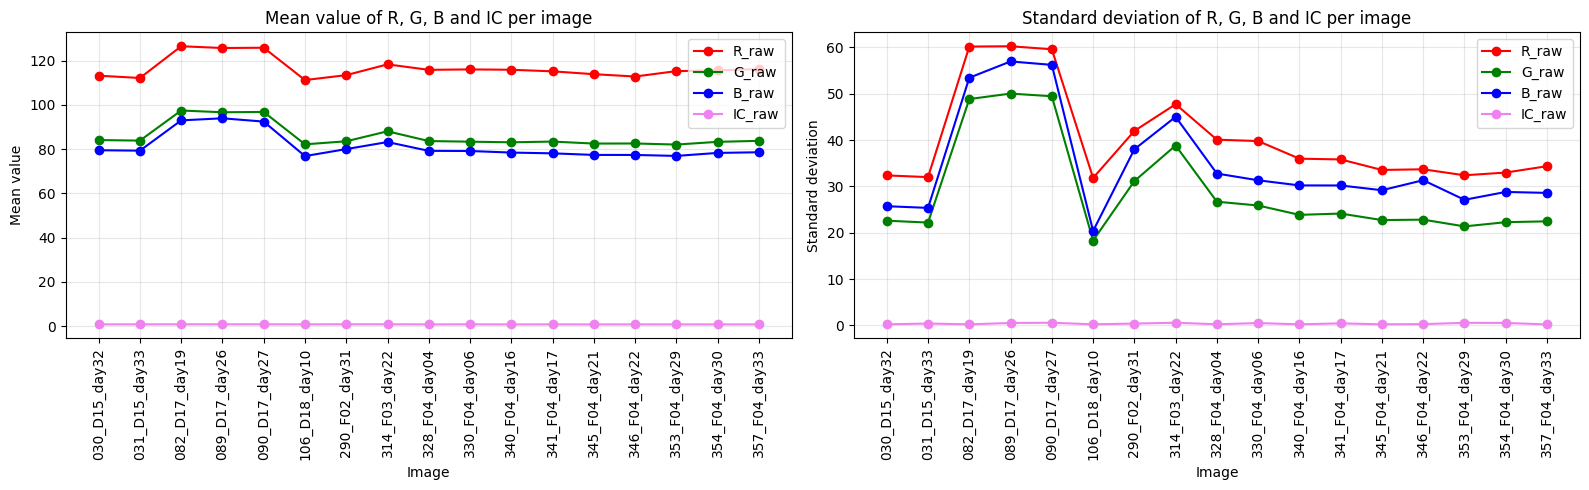

In [4]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

color_features = {"R_raw": "red", "G_raw": "green", "B_raw": "blue", "IC_raw": "violet"}

# Subplot 1: Media
for f in features:
    ax1.plot(stats_img["image"], stats_img[f"{f}_mean"], marker="o", label=f, color=color_features[f])
ax1.set_xticks(range(len(stats_img["image"])))
ax1.set_xticklabels(stats_img["image"], rotation=90)
ax1.set_xlabel("Image")
ax1.set_ylabel("Mean value")
ax1.set_title("Mean value of R, G, B and IC per image")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Desviación estándar
for f in features:
    ax2.plot(stats_img["image"], stats_img[f"{f}_std"], marker="o", label=f, color=color_features[f])
ax2.set_xticks(range(len(stats_img["image"])))
ax2.set_xticklabels(stats_img["image"], rotation=90)
ax2.set_xlabel("Image")
ax2.set_ylabel("Standard deviation")
ax2.set_title("Standard deviation of R, G, B and IC per image")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadística descriptiva - media y desviación estándar de R, G, B e IC para cada clase (tormenta y no tormenta)

In [5]:
rows = []

for name, item in data.items():
    for cls in [0, 1]:
        idx = item["y"] == cls

        row = {
            "image": name,
            "class": cls,
            "n_pixels": np.sum(idx)
        }

        for f in features:
            values = item[f][idx]
            row[f"{f}_mean"] = np.mean(values)
            row[f"{f}_std"] = np.std(values)
        rows.append(row)

stats_class = pd.DataFrame(rows)
# display(stats_class)

# Correlación promedio entre bandas

In [6]:
corr_matrices = []

for name, item in data.items():
    X = np.column_stack([item[f] for f in features])
    corr = np.corrcoef(X, rowvar=False)
    corr_matrices.append(corr)

mean_corr = np.mean(corr_matrices, axis=0)
mean_corr_df = pd.DataFrame(mean_corr, index=features, columns=features)
display(mean_corr_df)

,R_raw,G_raw,B_raw,IC_raw
R_raw,1.000000,0.728119,0.547386,-0.356027
G_raw,0.728119,1.000000,0.848965,0.018887
B_raw,0.547386,0.848965,1.000000,0.293350
IC_raw,-0.356027,0.018887,0.293350,1.000000


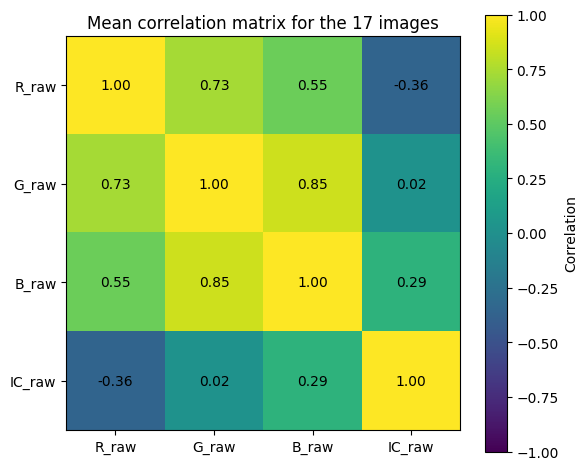

In [7]:
plt.figure(figsize=(6, 5))

plt.imshow(mean_corr, vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(features)), features)
plt.yticks(range(len(features)), features)

for i in range(len(features)):
    for j in range(len(features)):
        plt.text(j, i, f"{mean_corr[i, j]:.2f}", ha="center", va="center")

plt.title("Mean correlation matrix for the 17 images")
plt.tight_layout()
plt.show()

# Histogramas de cada banda

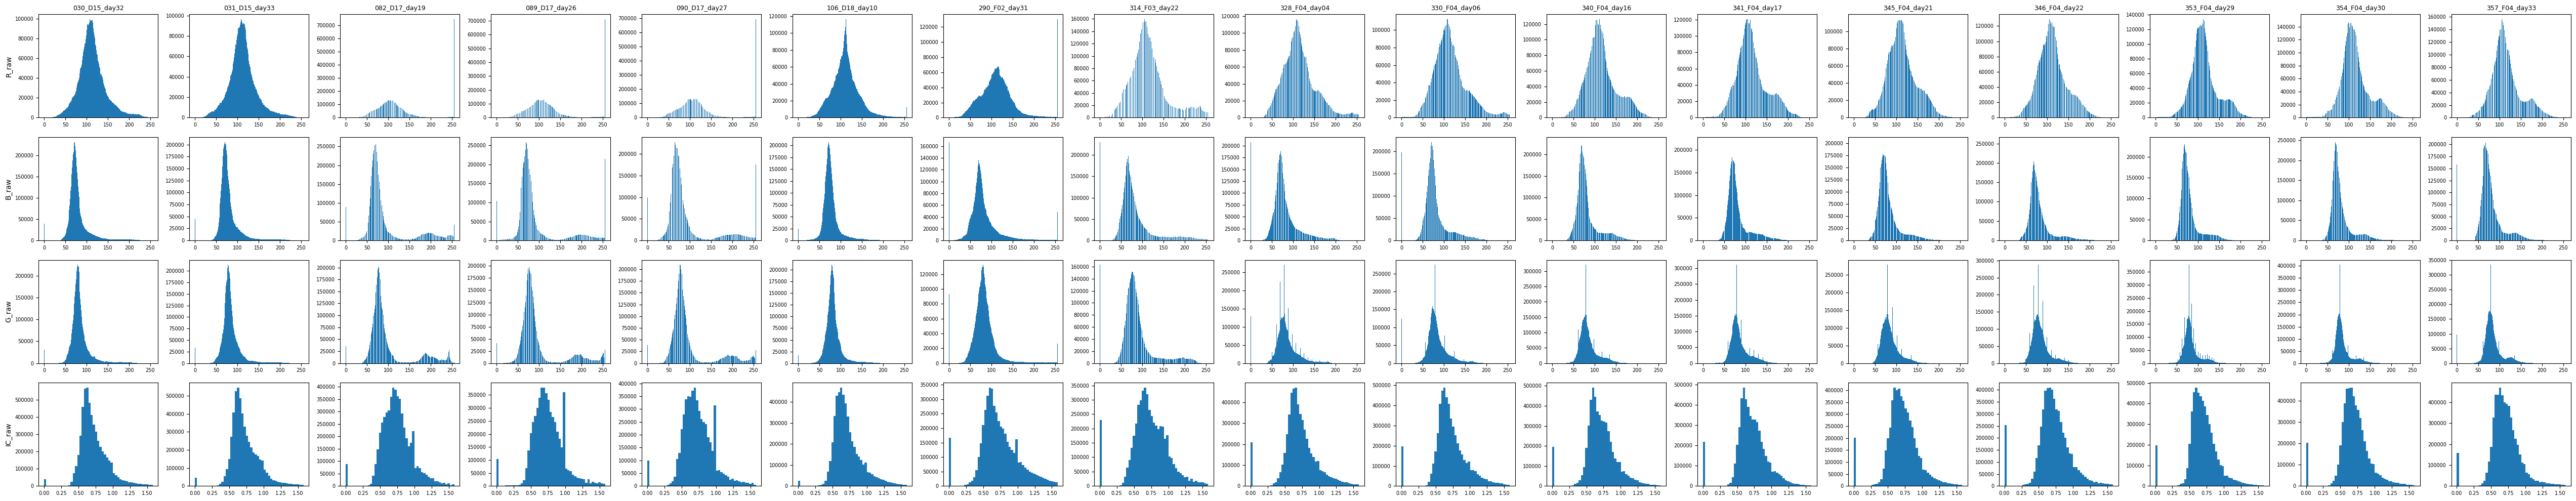

In [8]:
import numpy as np
import matplotlib.pyplot as plt

image_names = list(data.keys())
features = ["R_raw", "B_raw", "G_raw", "IC_raw"]

bins_rgb = np.arange(257) - 0.5
ic_all = np.concatenate([data[name]["IC_raw"] for name in image_names])
ic_min, ic_max = np.percentile(ic_all, [1, 99])
bins_ic = np.linspace(ic_min, ic_max, 50)

fig, axes = plt.subplots(4, len(image_names), figsize=(3*len(image_names), 10))

for j, name in enumerate(image_names):
    for i, f in enumerate(features):
        ax = axes[i, j]
        values = data[name][f]

        if f == "IC_raw":
            ax.hist(values, bins=bins_ic)
        else:
            ax.hist(values, bins=bins_rgb)

        if i == 0:
            ax.set_title(name, fontsize=9)

        if j == 0:
            ax.set_ylabel(f, fontsize=10)

        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

# <span style="color:#17a2b8;"> Muestreo aleatorio y selección de bandas</span>
Objetivo:
1. qué bandas separan mejor tormenta y no tormenta;
2. qué imágenes son más útiles o más difíciles;
3. si IC_raw aporta información adicional frente a R_raw, G_raw, B_raw.

# Crear muestra aleatoria balanceada por imagen y clase

In [9]:
features = ["R_raw", "G_raw", "B_raw", "IC_raw"]
n_per_class = 3000
np.random.seed(42)

rows = []

for name, item in data.items():
    y = item["y"]

    for cls in [0, 1]:
        idx_cls = np.where(y == cls)[0]

        if len(idx_cls) == 0:
            continue

        idx_sample = np.random.choice(
            idx_cls,
            size=min(n_per_class, len(idx_cls)),
            replace=False
        )

        df_temp = pd.DataFrame({
            "image": name,
            "class": cls,
            "R_raw": item["R_raw"][idx_sample],
            "G_raw": item["G_raw"][idx_sample],
            "B_raw": item["B_raw"][idx_sample],
            "IC_raw": item["IC_raw"][idx_sample],
        })

        rows.append(df_temp)
sample_df = pd.concat(rows, ignore_index=True)
# display(sample_df.head())

# Balance de clases por imagen

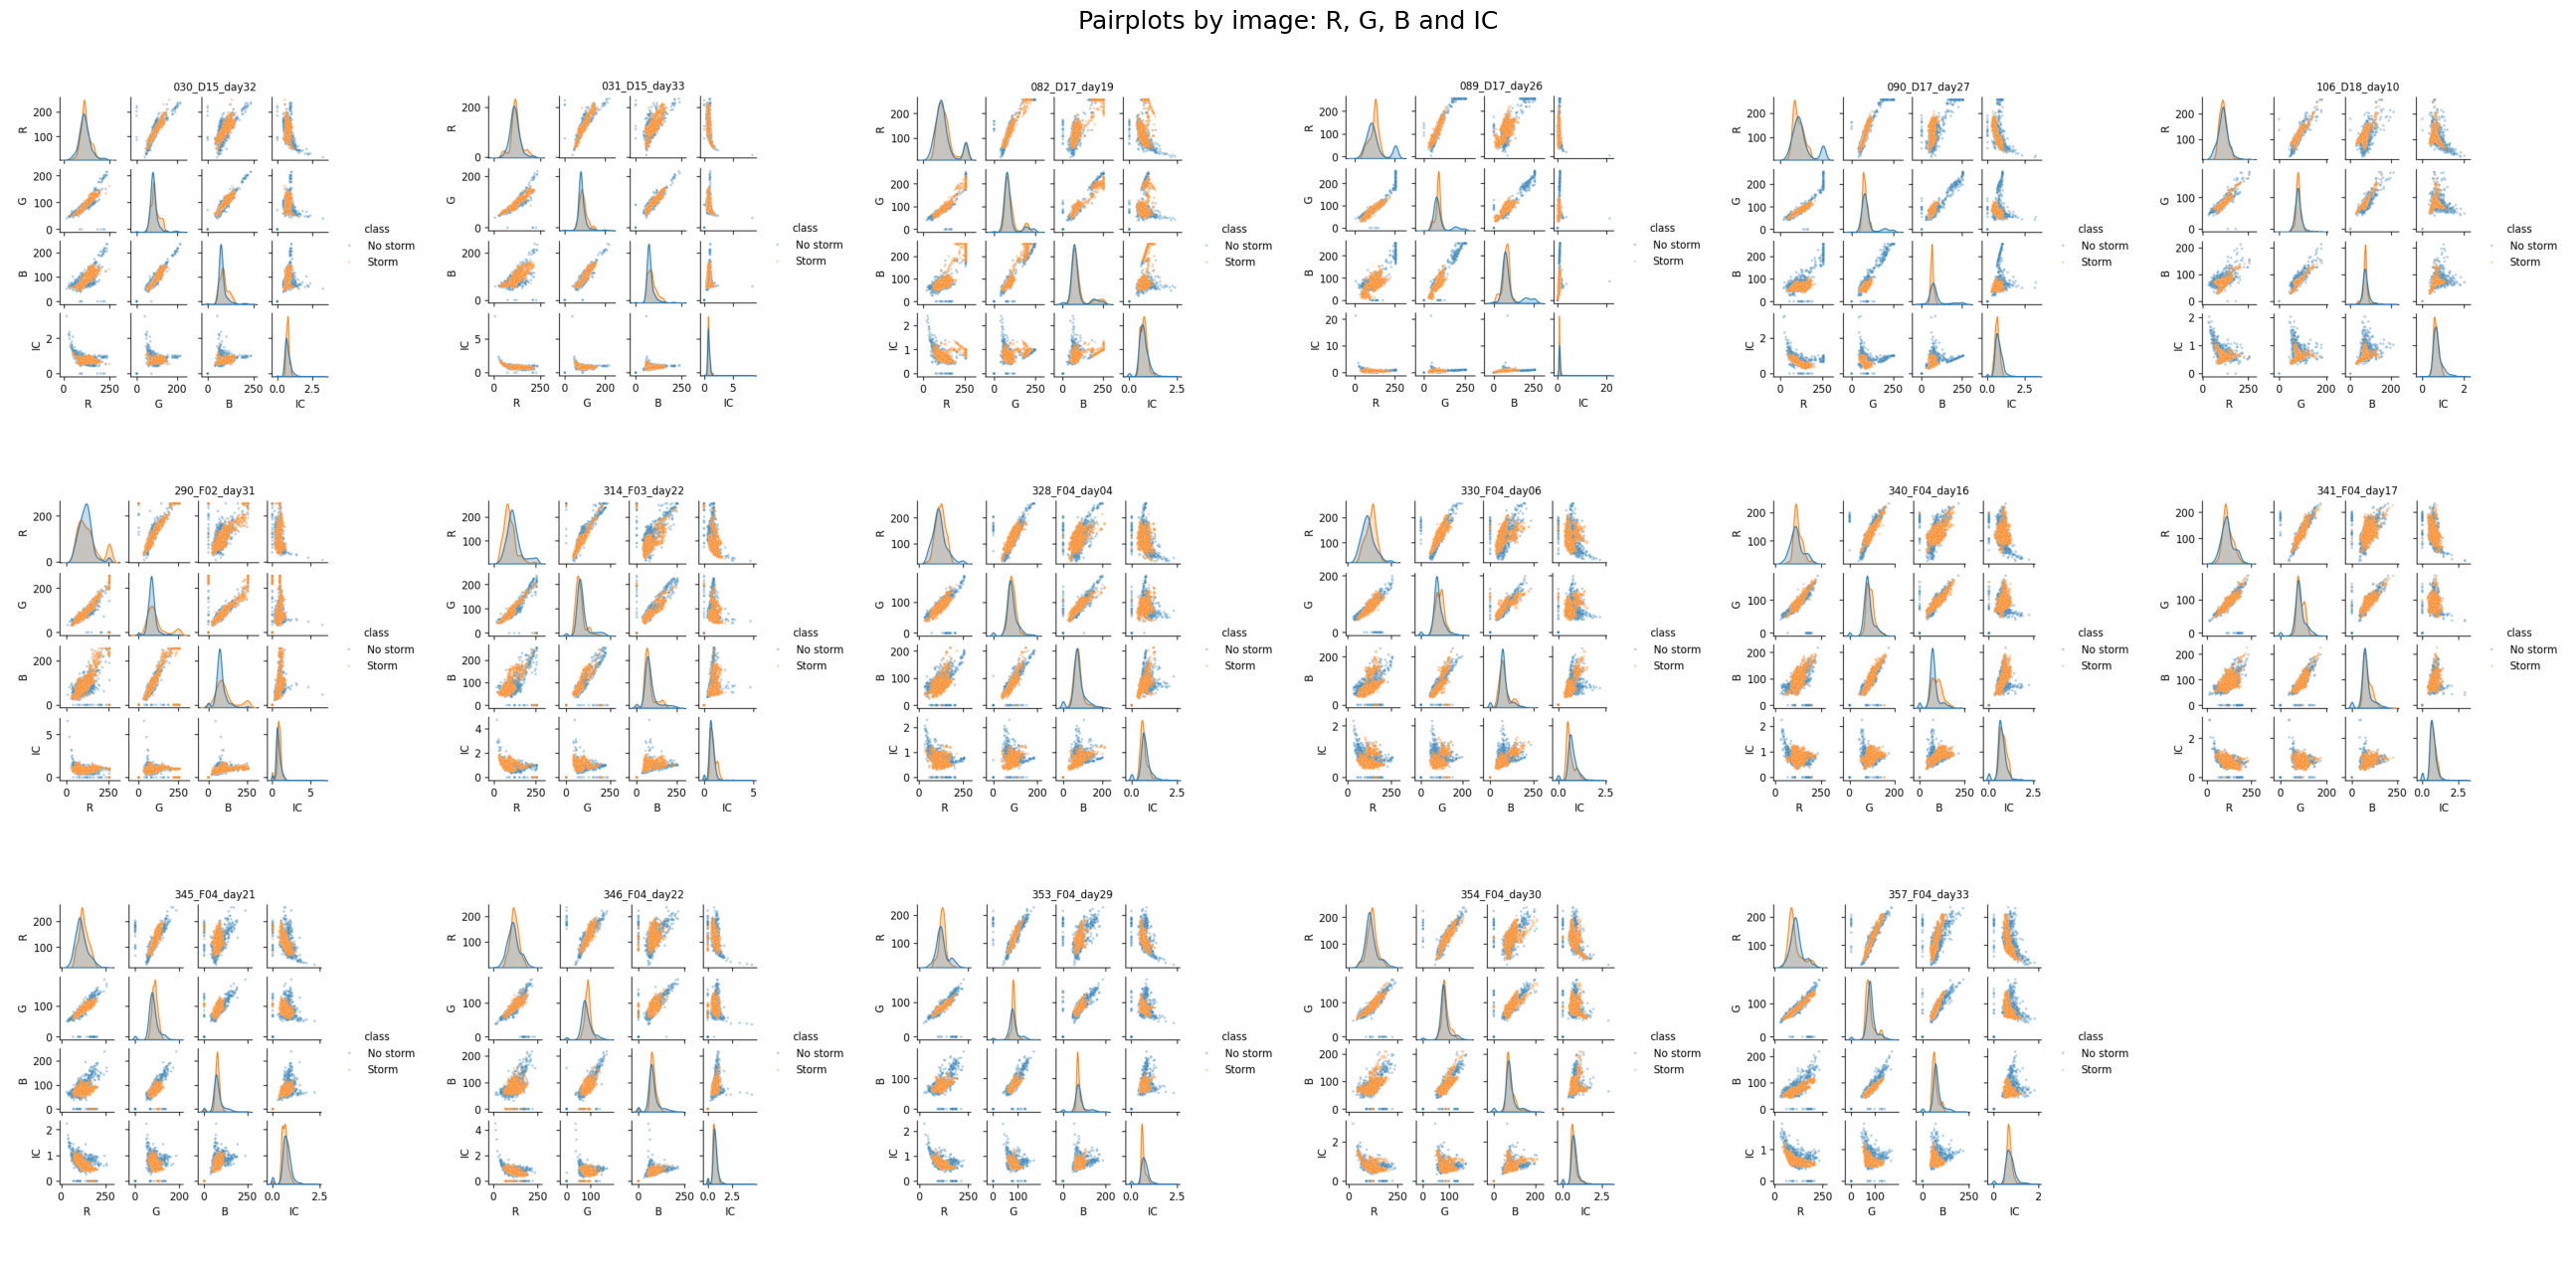

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

np.random.seed(42)

features = ["R_raw", "G_raw", "B_raw", "IC_raw"]
labels = {0: "No storm", 1: "Storm"}
n_per_class = 1000

pairplot_images = []

for name, item in data.items():

    df = pd.concat([
        pd.DataFrame({
            "R": item["R_raw"][idx],
            "G": item["G_raw"][idx],
            "B": item["B_raw"][idx],
            "IC": item["IC_raw"][idx],
            "class": labels[cls]
        })
        for cls in [0, 1]
        for idx_cls in [np.where(item["y"] == cls)[0]]
        if len(idx_cls) > 0
        for idx in [np.random.choice(idx_cls, min(n_per_class, len(idx_cls)), replace=False)]
    ])

    g = sns.pairplot(df, vars=["R", "G", "B", "IC"], hue="class", diag_kind="kde", plot_kws={"s": 6, "alpha": 0.35}, diag_kws={"fill": True}, height=1.1)

    g.fig.suptitle(name, y=1.02, fontsize=10)

    buffer = BytesIO()
    g.fig.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    buffer.seek(0)

    pairplot_images.append(Image.open(buffer).copy())
    plt.close(g.fig)


fig, axes = plt.subplots(3, 6, figsize=(26, 13))
axes = axes.ravel()

for ax, img in zip(axes, pairplot_images):
    ax.imshow(img)
    ax.axis("off")

for ax in axes[len(pairplot_images):]:
    ax.axis("off")

plt.suptitle("Pairplots by image: R, G, B and IC", fontsize=18)
plt.tight_layout()
plt.show()

# <span style="color:#17a2b8;"> Se vuelven a redefinir los datos ahora con más datos por pixel (Esto tampoco funcionó, no usar)</span>
- Es necesario volver a tomar las imagenes 2D
- Se realiza un analisis del promedio y la desviación estanar de los vecinos de cada pixel

# Redefininedo el dataframe con los nuevos datos por pixel (no funcionó, no usar)

In [11]:
# from pathlib import Path
# import cv2
# import numpy as np

# def color_extraction(route):
#     img = cv2.imread(route)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     return img[:, :, 0], img[:, :, 1], img[:, :, 2]

# def local_mean_std(img, valid, k=5):
#     img = img.astype(np.float32)
#     valid = valid.astype(np.float32)

#     mean = cv2.blur(img * valid, (k, k)) / (cv2.blur(valid, (k, k)) + 1e-8)
#     mean2 = cv2.blur((img**2) * valid, (k, k)) / (cv2.blur(valid, (k, k)) + 1e-8)
#     std = np.sqrt(np.maximum(mean2 - mean**2, 0))

#     return mean, std


# image_folder = Path("MARS/images")
# mask_folder = Path("MARS/masks_multiclass")

# data = {}
# k = 5   # local window size: 5x5

# for file in sorted(image_folder.glob("*.png")):
#     name = file.stem

#     R, G, B = color_extraction(str(file))

#     mask_path = mask_folder / f"{name}_multiclass.png"
#     mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

#     if mask is None:
#         print(f"Mask not found for: {name}")
#         continue

#     if mask.shape != R.shape:
#         print(f"Shape mismatch in: {name}")
#         continue

#     valid = (mask != 2) & (R > 0)

#     R2 = R.astype(np.float32)
#     G2 = G.astype(np.float32)
#     B2 = B.astype(np.float32)

#     IC2 = np.zeros_like(R2, dtype=np.float32)
#     IC2[valid] = B2[valid] / R2[valid]

#     R_mean, R_std = local_mean_std(R2, valid, k)
#     G_mean, G_std = local_mean_std(G2, valid, k)
#     B_mean, B_std = local_mean_std(B2, valid, k)
#     IC_mean, IC_std = local_mean_std(IC2, valid, k)

#     data[name] = {
#         "R_raw": R2[valid],
#         "G_raw": G2[valid],
#         "B_raw": B2[valid],
#         "IC_raw": IC2[valid],

#         "R_mean_local": R_mean[valid],
#         "G_mean_local": G_mean[valid],
#         "B_mean_local": B_mean[valid],
#         "IC_mean_local": IC_mean[valid],

#         "R_std_local": R_std[valid],
#         "G_std_local": G_std[valid],
#         "B_std_local": B_std[valid],
#         "IC_std_local": IC_std[valid],

#         "y": mask[valid]
#     }

In [12]:
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# features = [
#     "R_raw", "G_raw", "B_raw", "IC_raw",
#     "R_mean_local", "G_mean_local", "B_mean_local", "IC_mean_local",
#     "R_std_local", "G_std_local", "B_std_local", "IC_std_local"
# ]

# n_per_class = 300
# np.random.seed(42)

# for name, item in data.items():

#     rows = []

#     for cls in [0, 1]:
#         idx_cls = np.where(item["y"] == cls)[0]

#         if len(idx_cls) == 0:
#             continue

#         idx = np.random.choice(
#             idx_cls,
#             size=min(n_per_class, len(idx_cls)),
#             replace=False
#         )

#         df_cls = pd.DataFrame({
#             f: item[f][idx] for f in features
#         })

#         df_cls["class"] = "Storm" if cls == 1 else "No storm"
#         rows.append(df_cls)

#     df_img = pd.concat(rows, ignore_index=True)

#     g = sns.pairplot(
#         df_img,
#         vars=features,
#         hue="class",
#         diag_kind="kde",
#         plot_kws={"s": 5, "alpha": 0.35},
#         diag_kws={"fill": False, "warn_singular": False},
#         height=1.2
#     )

#     g.fig.suptitle(f"Pairplot - {name}", y=1.02, fontsize=14)
#     plt.show()